In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
columns=['center','left','right','steering','throttle','reverse','speed']
data=pd.read_csv("data\driving_log.csv",names=columns)
data.head()


,center,left,right,steering,throttle,reverse,speed
0,C:\Users\Amer\Desktop\new_track\IMG\center_201...,C:\Users\Amer\Desktop\new_track\IMG\left_2018_...,C:\Users\Amer\Desktop\new_track\IMG\right_2018...,0.0,0.0,0.0,0.649786
1,C:\Users\Amer\Desktop\new_track\IMG\center_201...,C:\Users\Amer\Desktop\new_track\IMG\left_2018_...,C:\Users\Amer\Desktop\new_track\IMG\right_2018...,0.0,0.0,0.0,0.627942
2,C:\Users\Amer\Desktop\new_track\IMG\center_201...,C:\Users\Amer\Desktop\new_track\IMG\left_2018_...,C:\Users\Amer\Desktop\new_track\IMG\right_2018...,0.0,0.0,0.0,0.622910
3,C:\Users\Amer\Desktop\new_track\IMG\center_201...,C:\Users\Amer\Desktop\new_track\IMG\left_2018_...,C:\Users\Amer\Desktop\new_track\IMG\right_2018...,0.0,0.0,0.0,0.619162
4,C:\Users\Amer\Desktop\new_track\IMG\center_201...,C:\Users\Amer\Desktop\new_track\IMG\left_2018_...,C:\Users\Amer\Desktop\new_track\IMG\right_2018...,0.0,0.0,0.0,0.615438


In [3]:
import ntpath

def path(path):
    head,tail=ntpath.split(path)
    return tail
data['center']=data['center'].apply(path)
data['left']=data['left'].apply(path)
data['right']=data['right'].apply(path)

data.head()

,center,left,right,steering,throttle,reverse,speed
0,center_2018_07_16_17_11_43_382.jpg,left_2018_07_16_17_11_43_382.jpg,right_2018_07_16_17_11_43_382.jpg,0.0,0.0,0.0,0.649786
1,center_2018_07_16_17_11_43_670.jpg,left_2018_07_16_17_11_43_670.jpg,right_2018_07_16_17_11_43_670.jpg,0.0,0.0,0.0,0.627942
2,center_2018_07_16_17_11_43_724.jpg,left_2018_07_16_17_11_43_724.jpg,right_2018_07_16_17_11_43_724.jpg,0.0,0.0,0.0,0.622910
3,center_2018_07_16_17_11_43_792.jpg,left_2018_07_16_17_11_43_792.jpg,right_2018_07_16_17_11_43_792.jpg,0.0,0.0,0.0,0.619162
4,center_2018_07_16_17_11_43_860.jpg,left_2018_07_16_17_11_43_860.jpg,right_2018_07_16_17_11_43_860.jpg,0.0,0.0,0.0,0.615438


In [4]:
print(len(data))
print(data.shape)

4053
(4053, 7)


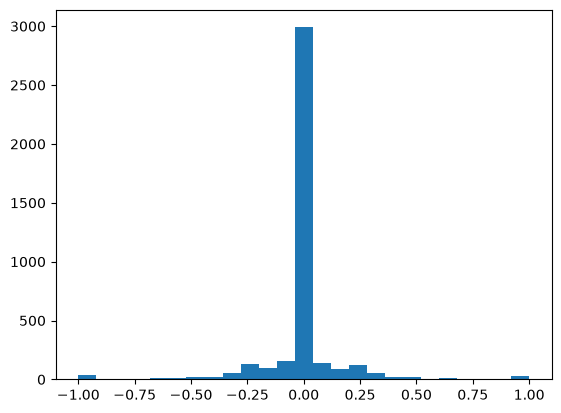

In [5]:
import matplotlib.pyplot as plt

hist, bins, _ = plt.hist(data["steering"], bins=25)
plt.show()
plt.close()   

In [6]:
from sklearn.utils import shuffle

samples_per_bin = 400
remove_list = []

for j in range(len(hist)):
    list_ = []

    for i in range(len(data["steering"])):
        if bins[j] <= data["steering"][i] <= bins[j + 1]:
            list_.append(i)

    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

data.drop(data.index[remove_list], inplace=True)

In [8]:
data.shape

(1463, 7)

In [13]:
import os
import numpy as np

def load_img_steering(datadir, data):

    image_path = []
    steering = []

    for i in range(len(data)):

        # Get one row from the DataFrame
        indexed_data = data.iloc[i]

        # Access values by position using .iloc
        center = indexed_data.iloc[0]
        left = indexed_data.iloc[1]
        right = indexed_data.iloc[2]
        steer = float(indexed_data.iloc[3])

        # Center image
        image_path.append(os.path.join(datadir, center.strip()))
        steering.append(steer)

        # Left image
        image_path.append(os.path.join(datadir, left.strip()))
        steering.append(steer + 0.15)

        # Right image
        image_path.append(os.path.join(datadir, right.strip()))
        steering.append(steer - 0.15)

    image_paths = np.asarray(image_path)
    steerings = np.asarray(steering)

    return image_paths, steerings

In [15]:
image_path,steerings=load_img_steering("data\IMG",data)

In [16]:
len(image_path)

4389

In [17]:
len(steerings)

4389

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid=train_test_split(image_path,steerings,test_size=0.2,random_state=6)
print(len(X_train))
print(len(X_valid))
print(len(y_train),len(y_valid))

3511
878
3511 878
